# Analyse SL-CR Experiment Results

Notebook for inspecting the merged ECLYPSE metric output, separating timeout and non-timeout events, and plotting the main Prolog reasoning metrics by topology.

## Setup

The input file is expected to be the merged parquet produced from the experiment logs. Change `RESULTS_PATH` if the file lives elsewhere.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RESULTS_PATH = Path(".") / "new.parquet"

METRICS = [
    # "prolog_inferences",
    "prolog_query_seconds",
    "placement_migrations",
]

TOPOLOGIES = [
    "ER",
    "BA",
    "IAG",
]

METRIC_LABELS = {
    "prolog_query_seconds": "Execution time [s]",
    "prolog_inferences": "Prolog inferences",
    "placement_migrations": "Migrations",
}

EVENT_COLS = [
    # "event_id",
    "n_event",
    "callback_id",
    "value",
    "mode",
    "nodes",
    "components",
    "seed",
    "topology",
]

## Load and inspect

In [2]:
df = pd.read_parquet(RESULTS_PATH, columns=EVENT_COLS)

print(f"rows: {len(df)}")
print(f"columns: {list(df.columns)}")

display(df.head())

rows: 189300
columns: ['n_event', 'callback_id', 'value', 'mode', 'nodes', 'components', 'seed', 'topology']


,n_event,callback_id,value,mode,nodes,components,seed,topology
0,1,prolog_query_seconds,1.472888e+00,cr,1000,300,3997,IAG
1,1,prolog_inferences,2.375436e+07,cr,1000,300,3997,IAG
2,1,placement_migrations,inf,cr,1000,300,3997,IAG
3,1,is_mapped,1.000000e+00,cr,1000,300,3997,IAG
4,1,query_timeout,0.000000e+00,cr,1000,300,3997,IAG


Split into two dataframes: one for timeout events, and one for non-timeout events. The timeout events are those where `callback_id` is `query_timeout` and `value` is 1. The non-timeout events are all the others.

In [3]:
group_cols = ["mode", "nodes", "components", "seed", "topology", "n_event"]

mask_timeout_row = (
    (df["callback_id"] == "query_timeout") &
    (df["value"] == 1)
)

timeout_groups = df.loc[mask_timeout_row, group_cols].drop_duplicates()

df_marked = df.merge(
    timeout_groups.assign(has_timeout=True),
    on=group_cols,
    how="left"
)

df_marked["has_timeout"] = df_marked["has_timeout"].fillna(False).astype(bool)

df_timeout = df_marked[df_marked["has_timeout"]].drop(columns="has_timeout")
df_no_timeout = df_marked[~df_marked["has_timeout"]].drop(columns="has_timeout")

In [4]:
event_cols = ["mode", "nodes", "components", "seed", "topology", "n_event"]

events_marked = (
    df_marked[event_cols + ["has_timeout"]]
    .drop_duplicates()
)

timeout_by_topology = (
    events_marked
    .groupby("topology", as_index=False)
    .agg(
        total_events=("has_timeout", "size"),
        timeout_events=("has_timeout", "sum"),
    )
)

timeout_by_topology["timeout_percentage"] = (
    100 * timeout_by_topology["timeout_events"] / timeout_by_topology["total_events"]
)

display(timeout_by_topology)

,topology,total_events,timeout_events,timeout_percentage
0,BA,15960,61,0.382206
1,ER,16000,36,0.225000
2,IAG,5900,22,0.372881


In [5]:
def quality_summary(df: pd.DataFrame) -> pd.DataFrame:
    quality_df = df.copy()
    quality_df["is_nan"] = quality_df["value"].isna()
    quality_df["is_inf"] = np.isinf(quality_df["value"])
    quality_df["is_bad"] = quality_df["is_nan"] | quality_df["is_inf"]

    summary = (
        quality_df.groupby("callback_id", as_index=False)
        .agg(
            rows=("value", "size"),
            nan_values=("is_nan", "sum"),
            inf_values=("is_inf", "sum"),
            bad_values=("is_bad", "sum"),
        )
    )

    display(summary)
quality_summary(df_no_timeout)

,callback_id,rows,nan_values,inf_values,bad_values
0,is_mapped,37741,0,0,0
1,placement_migrations,37741,0,12181,12181
2,prolog_inferences,37741,0,11801,11801
3,prolog_query_seconds,37741,0,11806,11806
4,query_timeout,37741,0,0,0


In [6]:
df_plot = df_no_timeout.copy()
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=["value"])

In [7]:
NODES_FILTER = None
COMPONENTS_FILTER = None
MODE_FILTER = None
TOPOLOGY_FILTER = None


def apply_filters(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    if NODES_FILTER is not None:
        out = out[out["nodes"] == NODES_FILTER]
    if COMPONENTS_FILTER is not None:
        out = out[out["components"] == COMPONENTS_FILTER]
    if MODE_FILTER is not None:
        out = out[out["mode"] == MODE_FILTER]
    if TOPOLOGY_FILTER is not None:
        out = out[out["topology"] == TOPOLOGY_FILTER]
    return out

print(f"rows before filters: {len(df_plot)}")
plot_df = apply_filters(df_plot)
plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")

print(f"rows after filters: {len(plot_df)}")

rows before filters: 152917
rows after filters: 152917


In [8]:
def remove_outliers_iqr(group, col="value", k=1.5):
    q1 = group[col].quantile(0.25)
    q3 = group[col].quantile(0.75)
    iqr = q3 - q1

    if iqr == 0 or pd.isna(iqr):
        return group

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    return group[
        (group[col] >= lower) &
        (group[col] <= upper)
    ]

def remove_outliers_zscore(group, col="value", threshold=3):
    std = group[col].std()

    if std == 0 or pd.isna(std):
        return group

    z = (group[col] - group[col].mean()) / std

    return group[np.abs(z) < threshold]


/var/folders/1r/_v8l8s4s5szdklfbt8tg7dwm0000gn/T/ipykernel_3509/4229250073.py:35: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


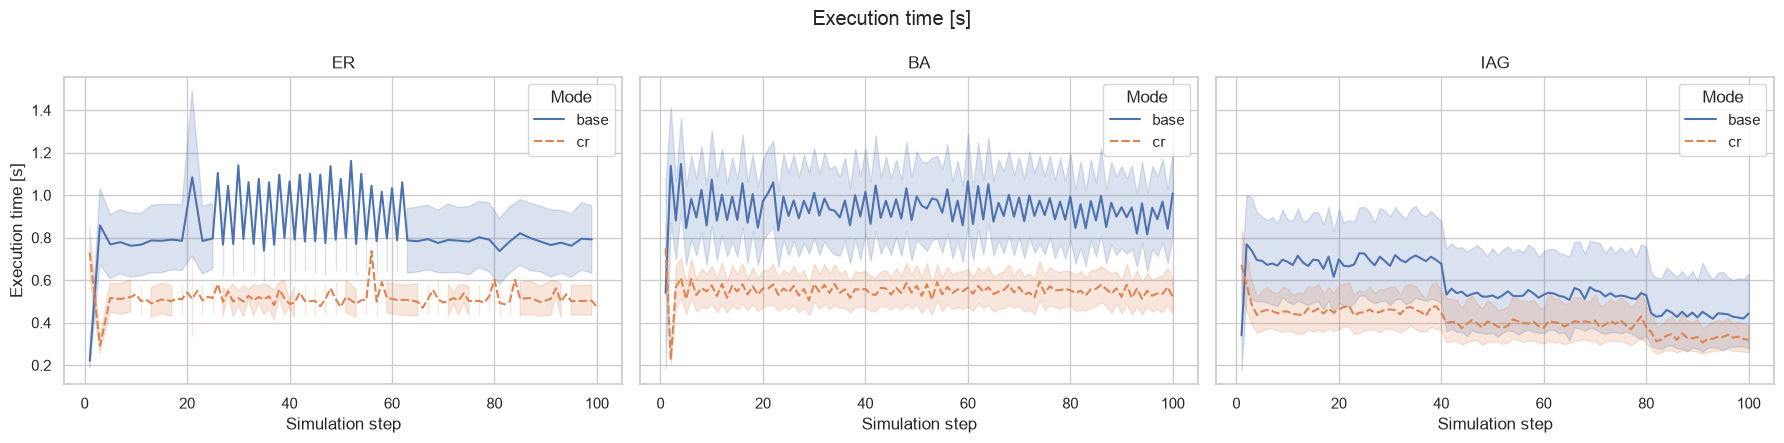

/var/folders/1r/_v8l8s4s5szdklfbt8tg7dwm0000gn/T/ipykernel_3509/4229250073.py:35: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


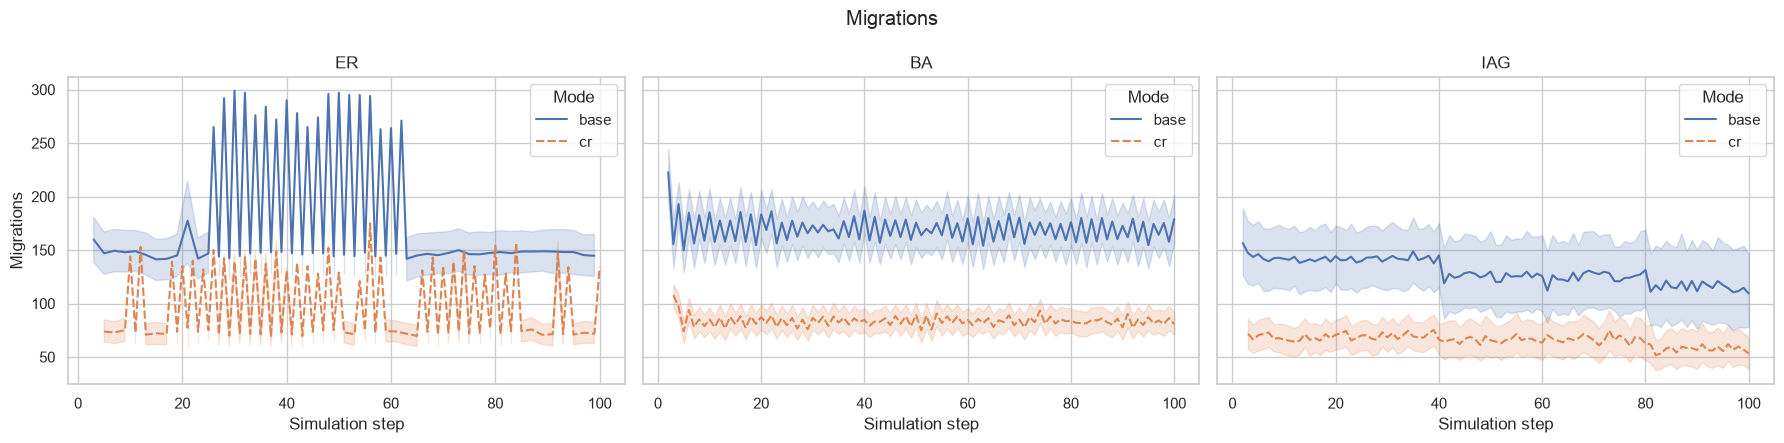

In [9]:
outlier_group_cols = ["mode", "nodes", "components", "topology"]
for metric in METRICS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True,  constrained_layout=True)

    for ax, topology in zip(axes, TOPOLOGIES):
        data = plot_df[
            (plot_df["callback_id"] == metric)
            & (plot_df["topology"] == topology)
        ]
        data = data.groupby(outlier_group_cols).apply(remove_outliers_iqr).copy()
        
        if data.empty:
            print(f"No data for metric '{metric}' and topology '{topology}' after outlier removal.")
            continue

        sns.lineplot(
            data=data,
            x="n_event",
            y="value",
            hue="mode",
            style="mode",
            marker=None,
            ax=ax,
        )

        ax.set_title(topology)
        ax.set_xlabel("Simulation step")
        ax.set_ylabel(METRIC_LABELS[metric])
        ax.grid(True)

        if ax.get_legend() is not None:
            ax.legend(title="Mode")

    fig.suptitle(f"{METRIC_LABELS[metric]}")
    fig.tight_layout()
    plt.show()

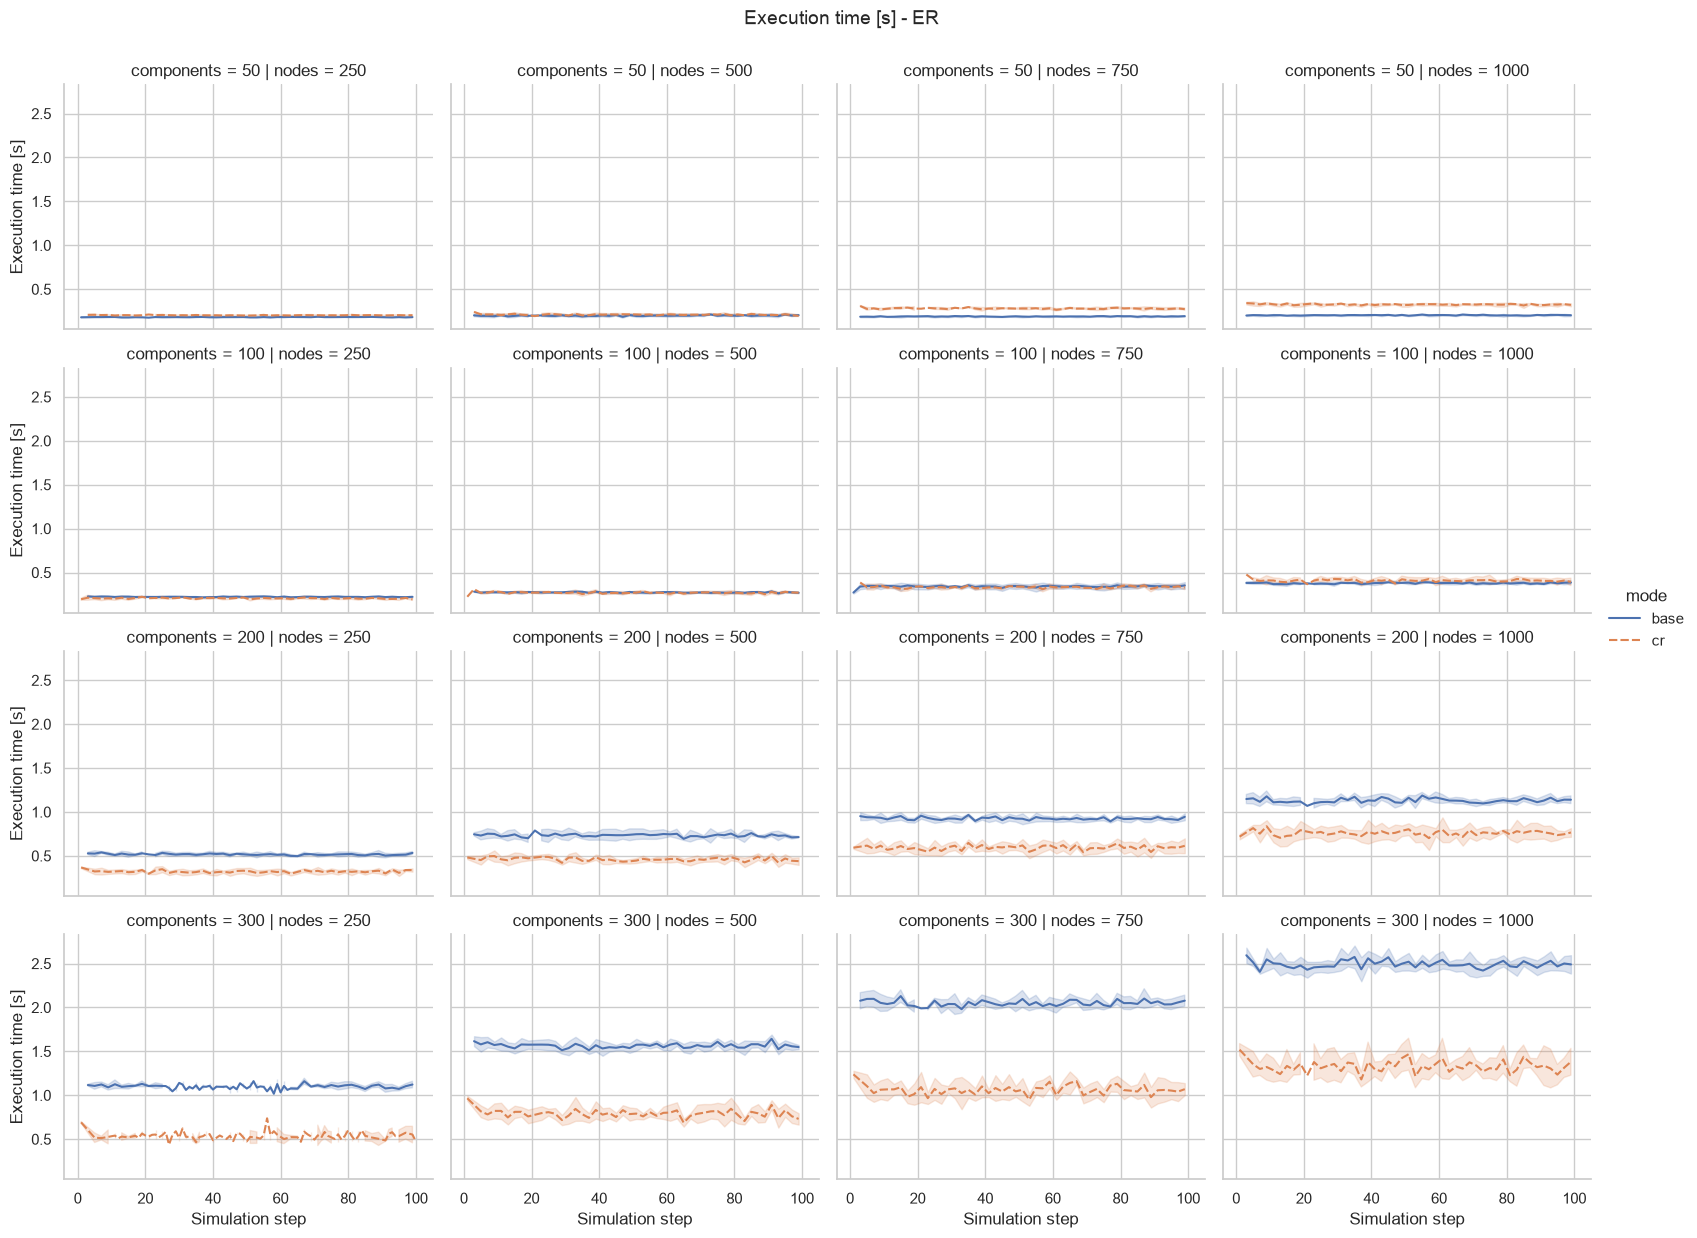

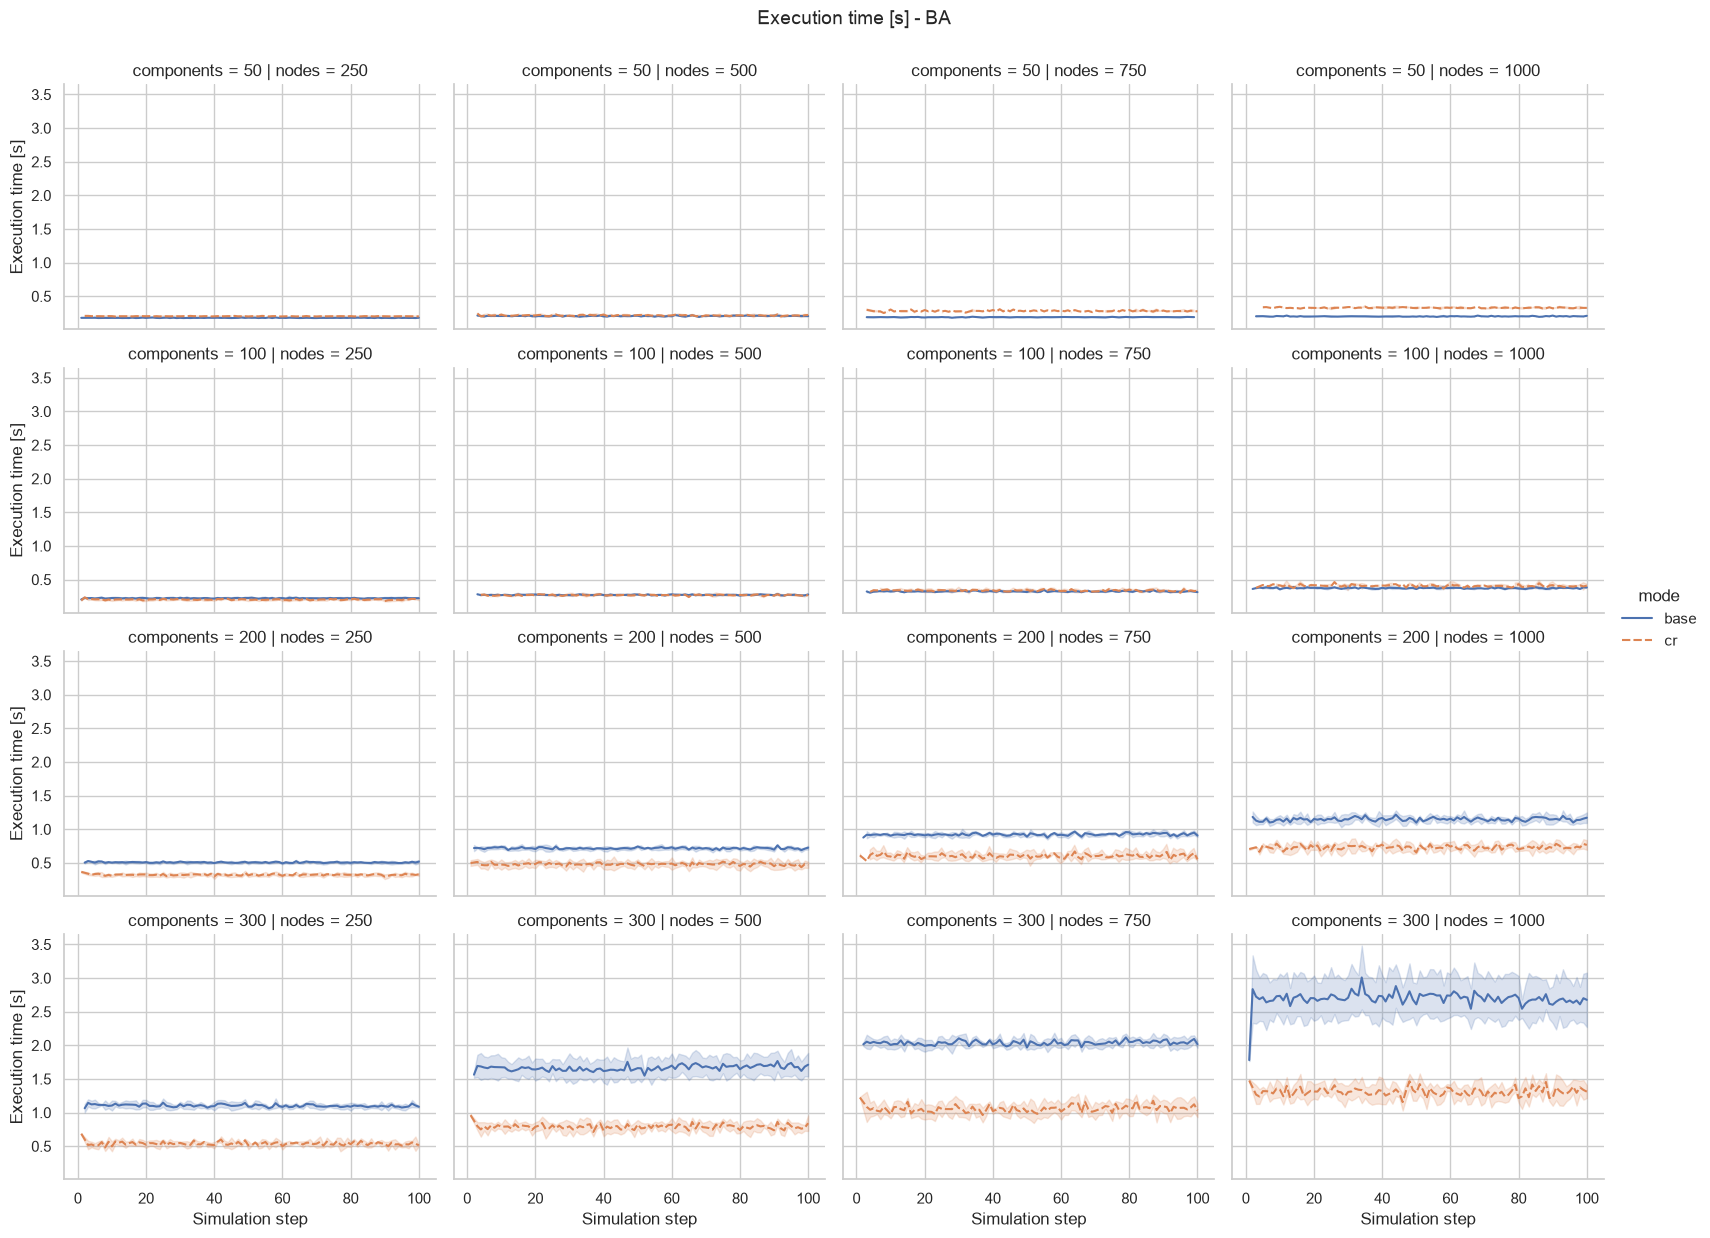

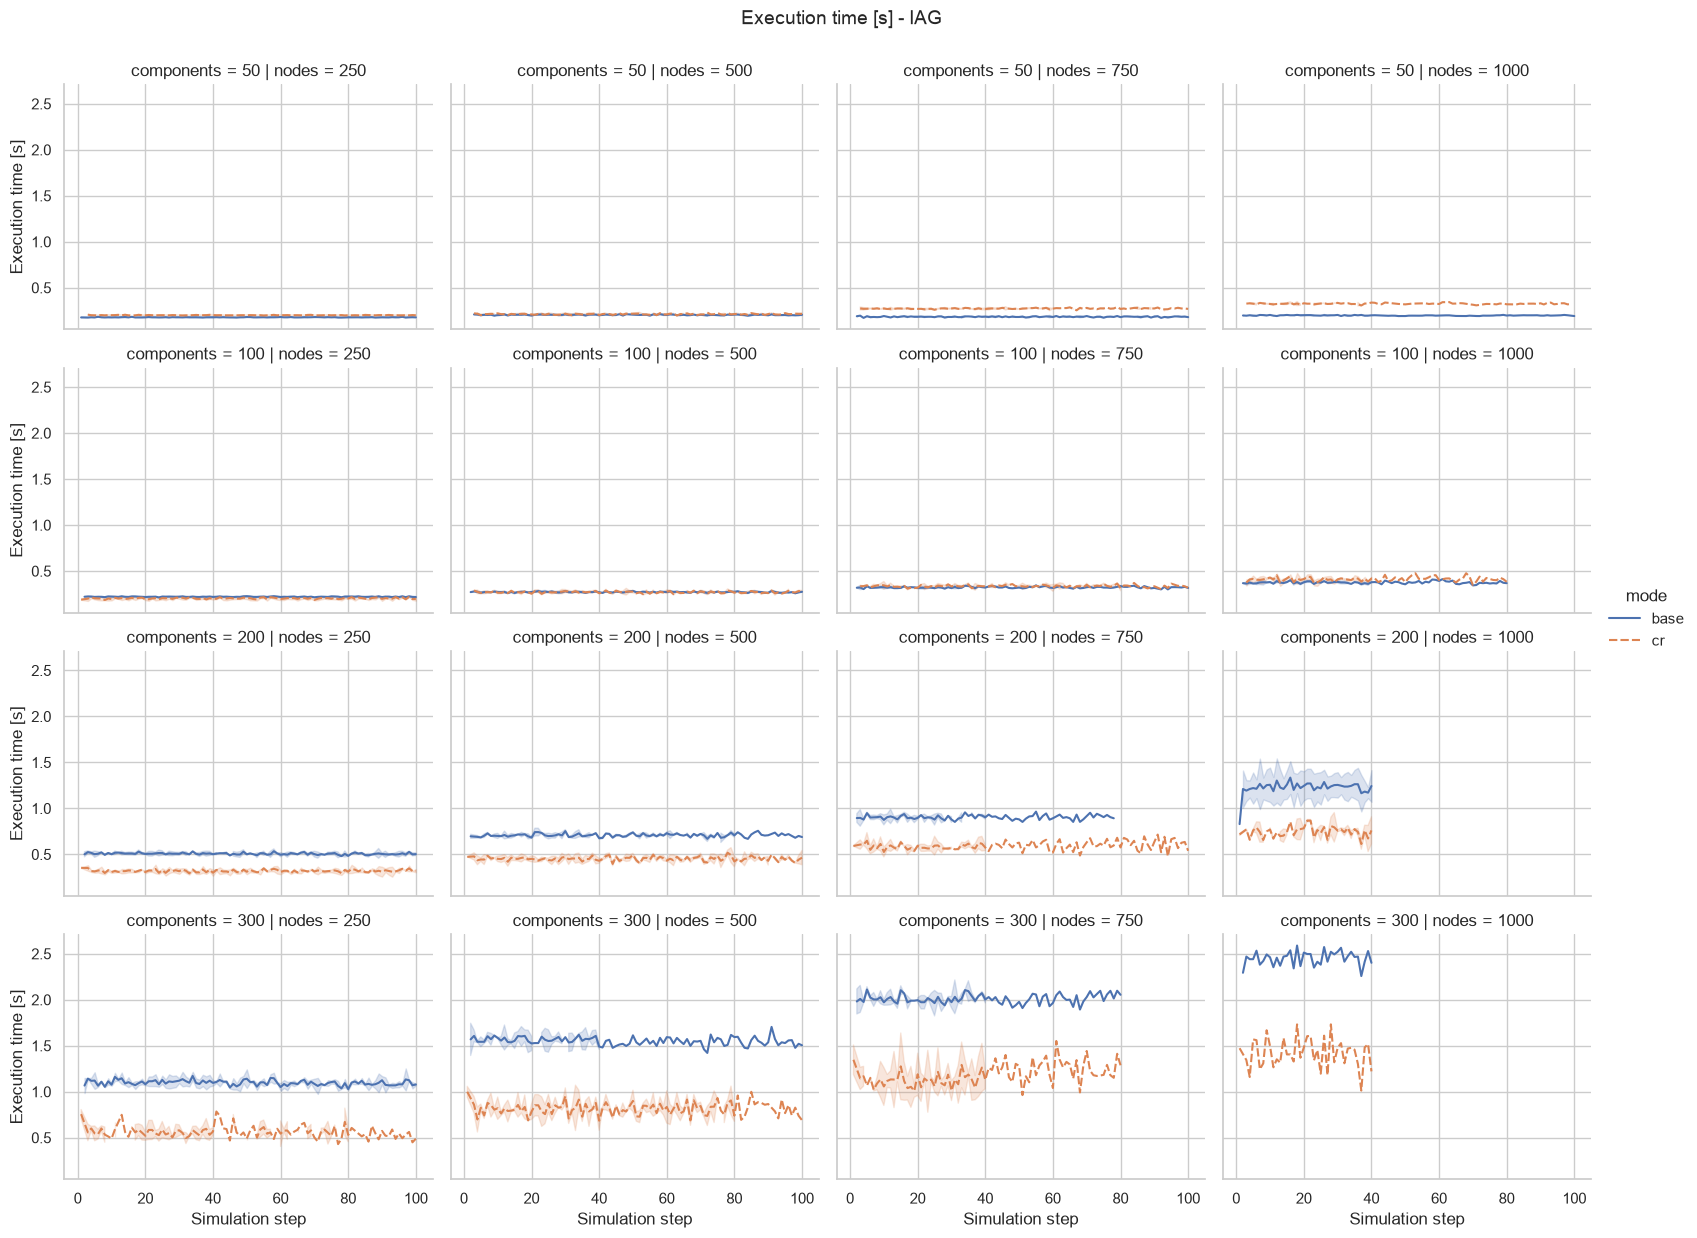

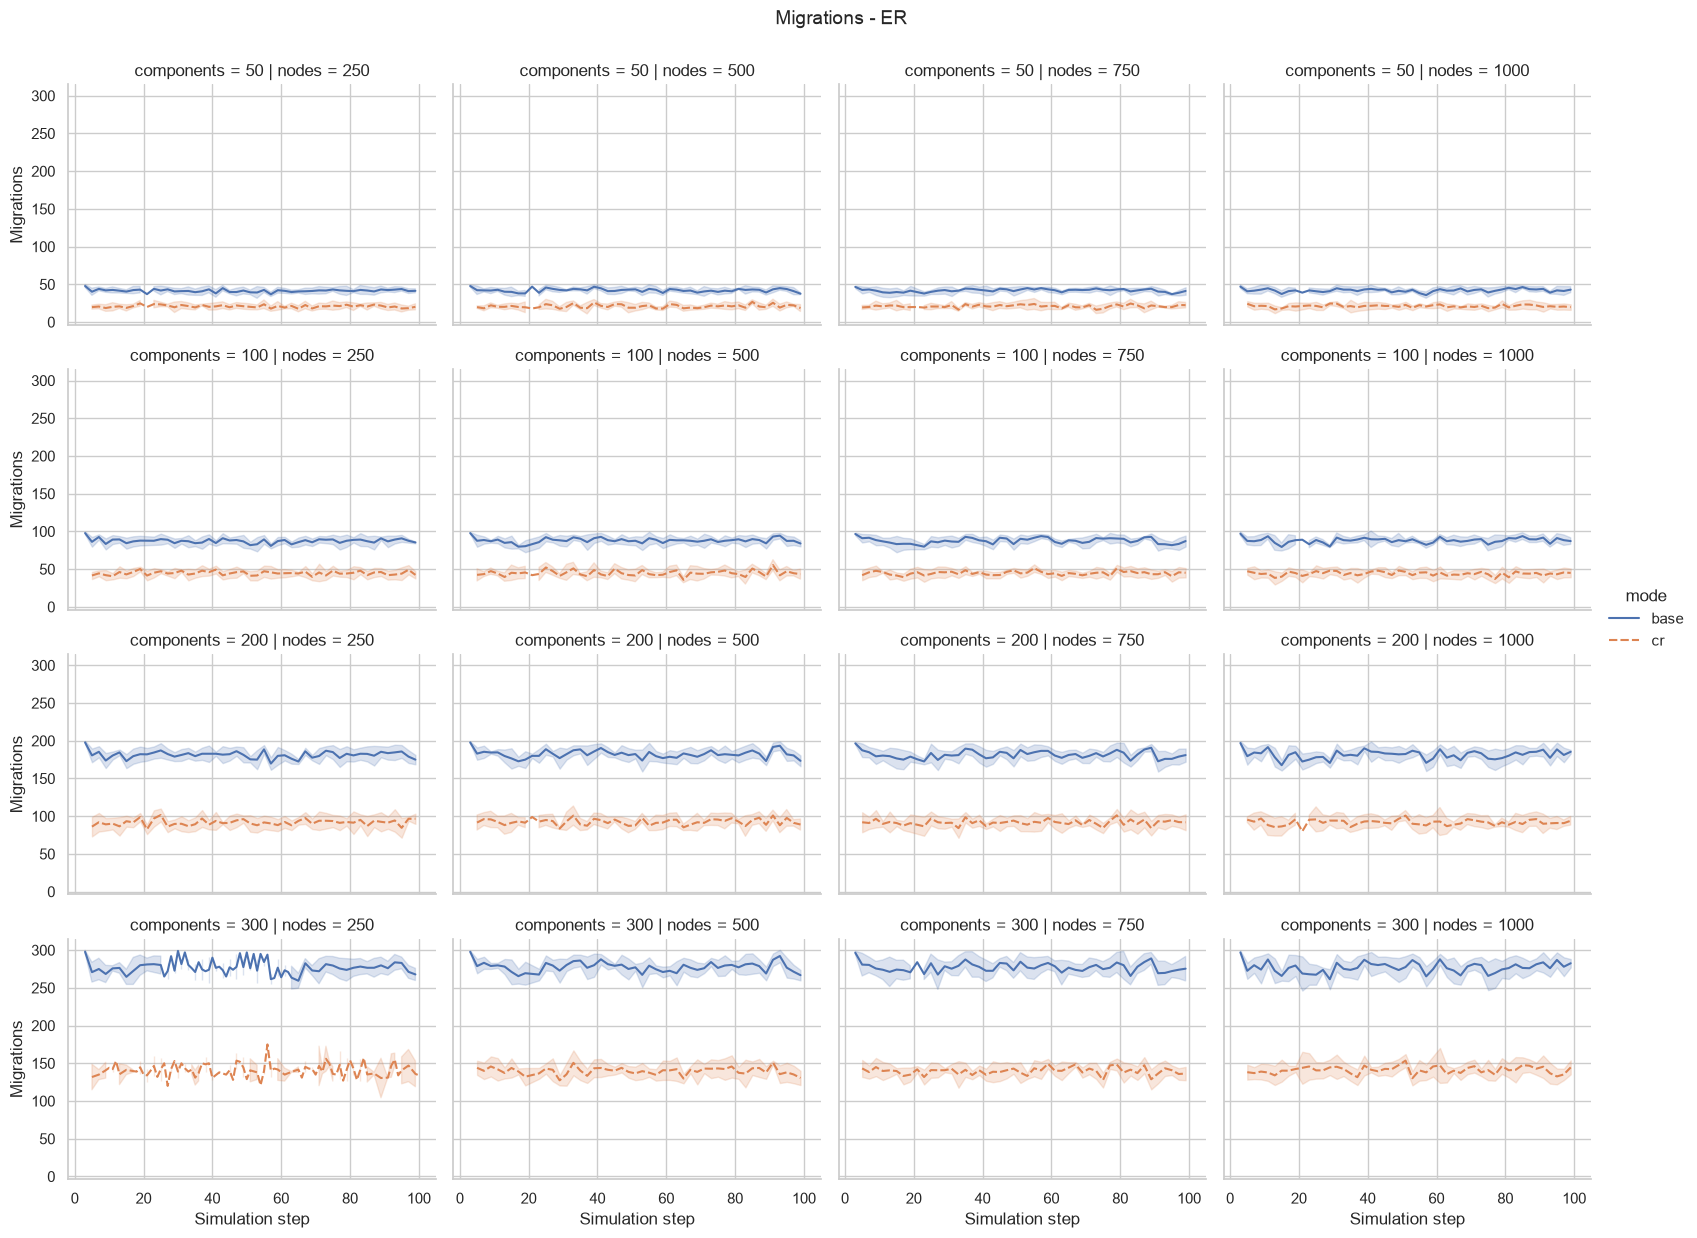

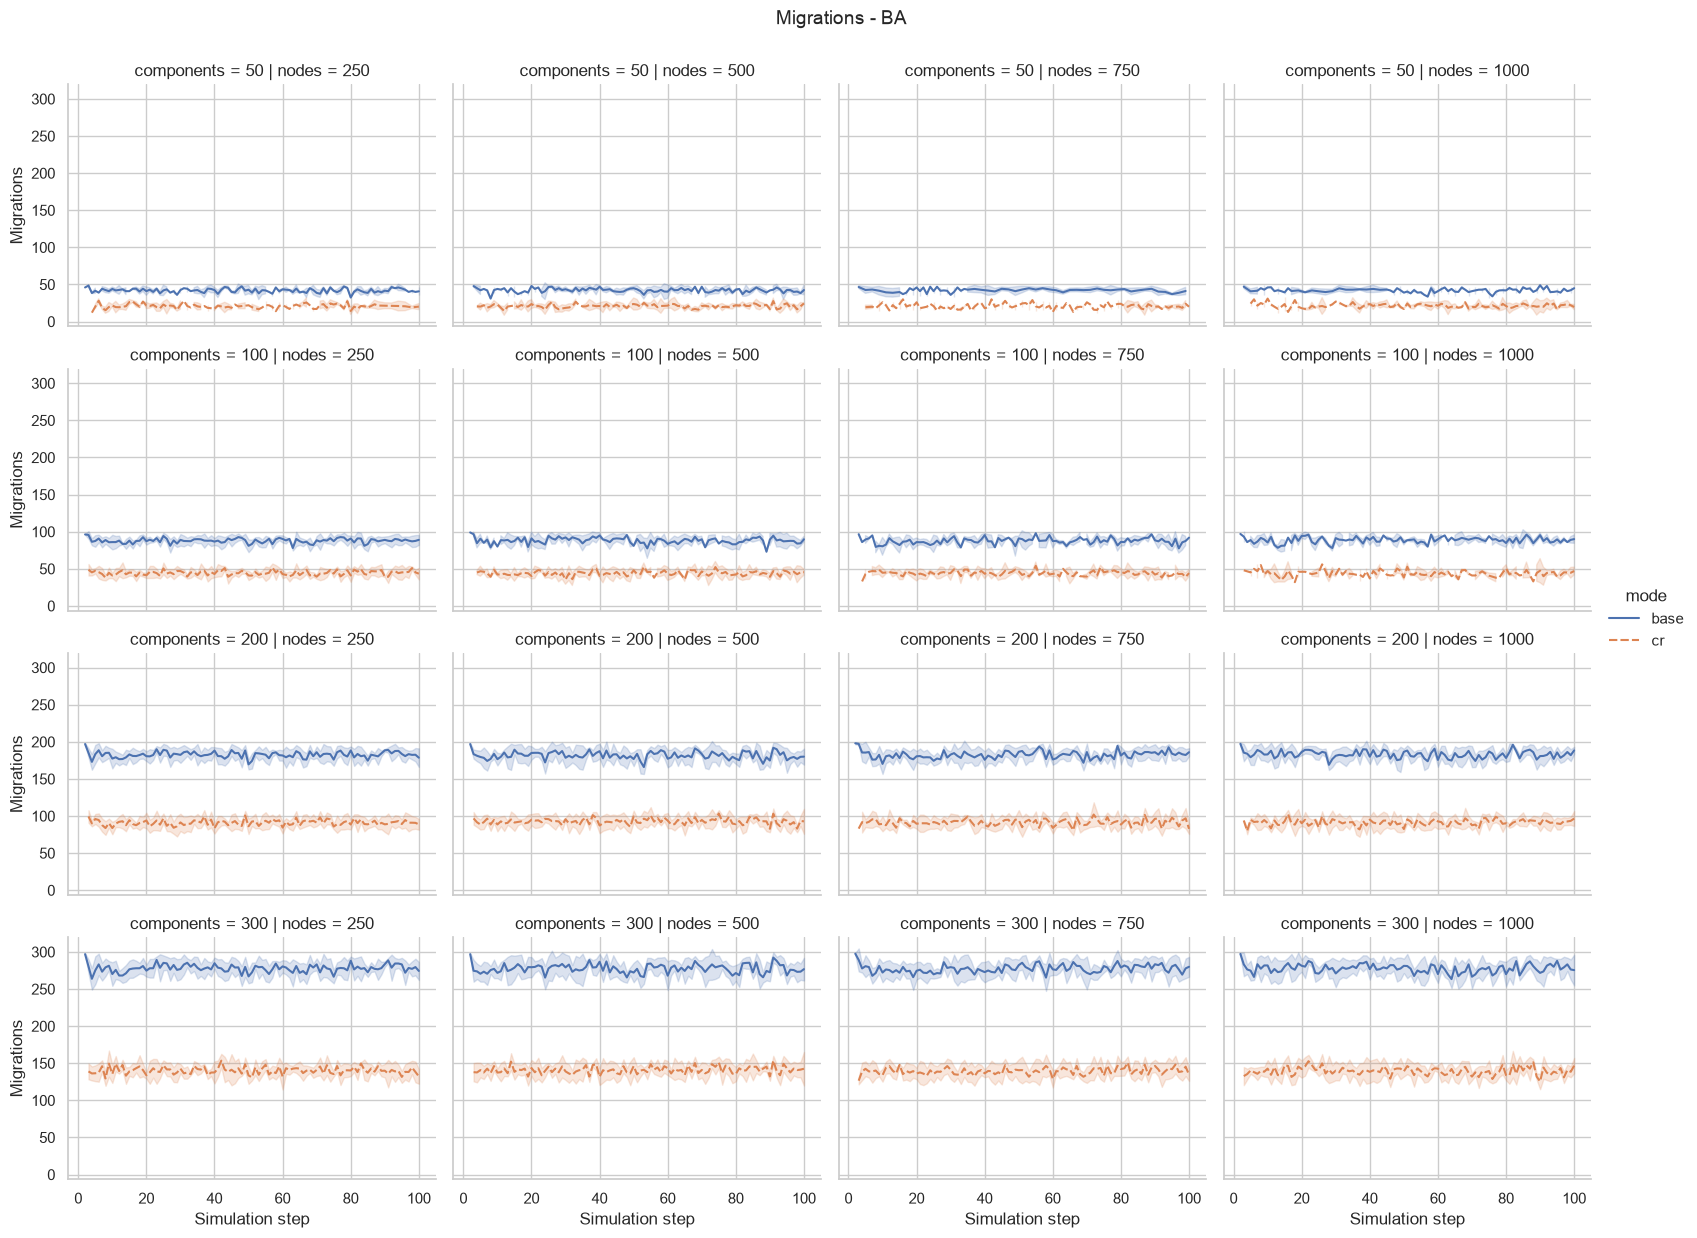

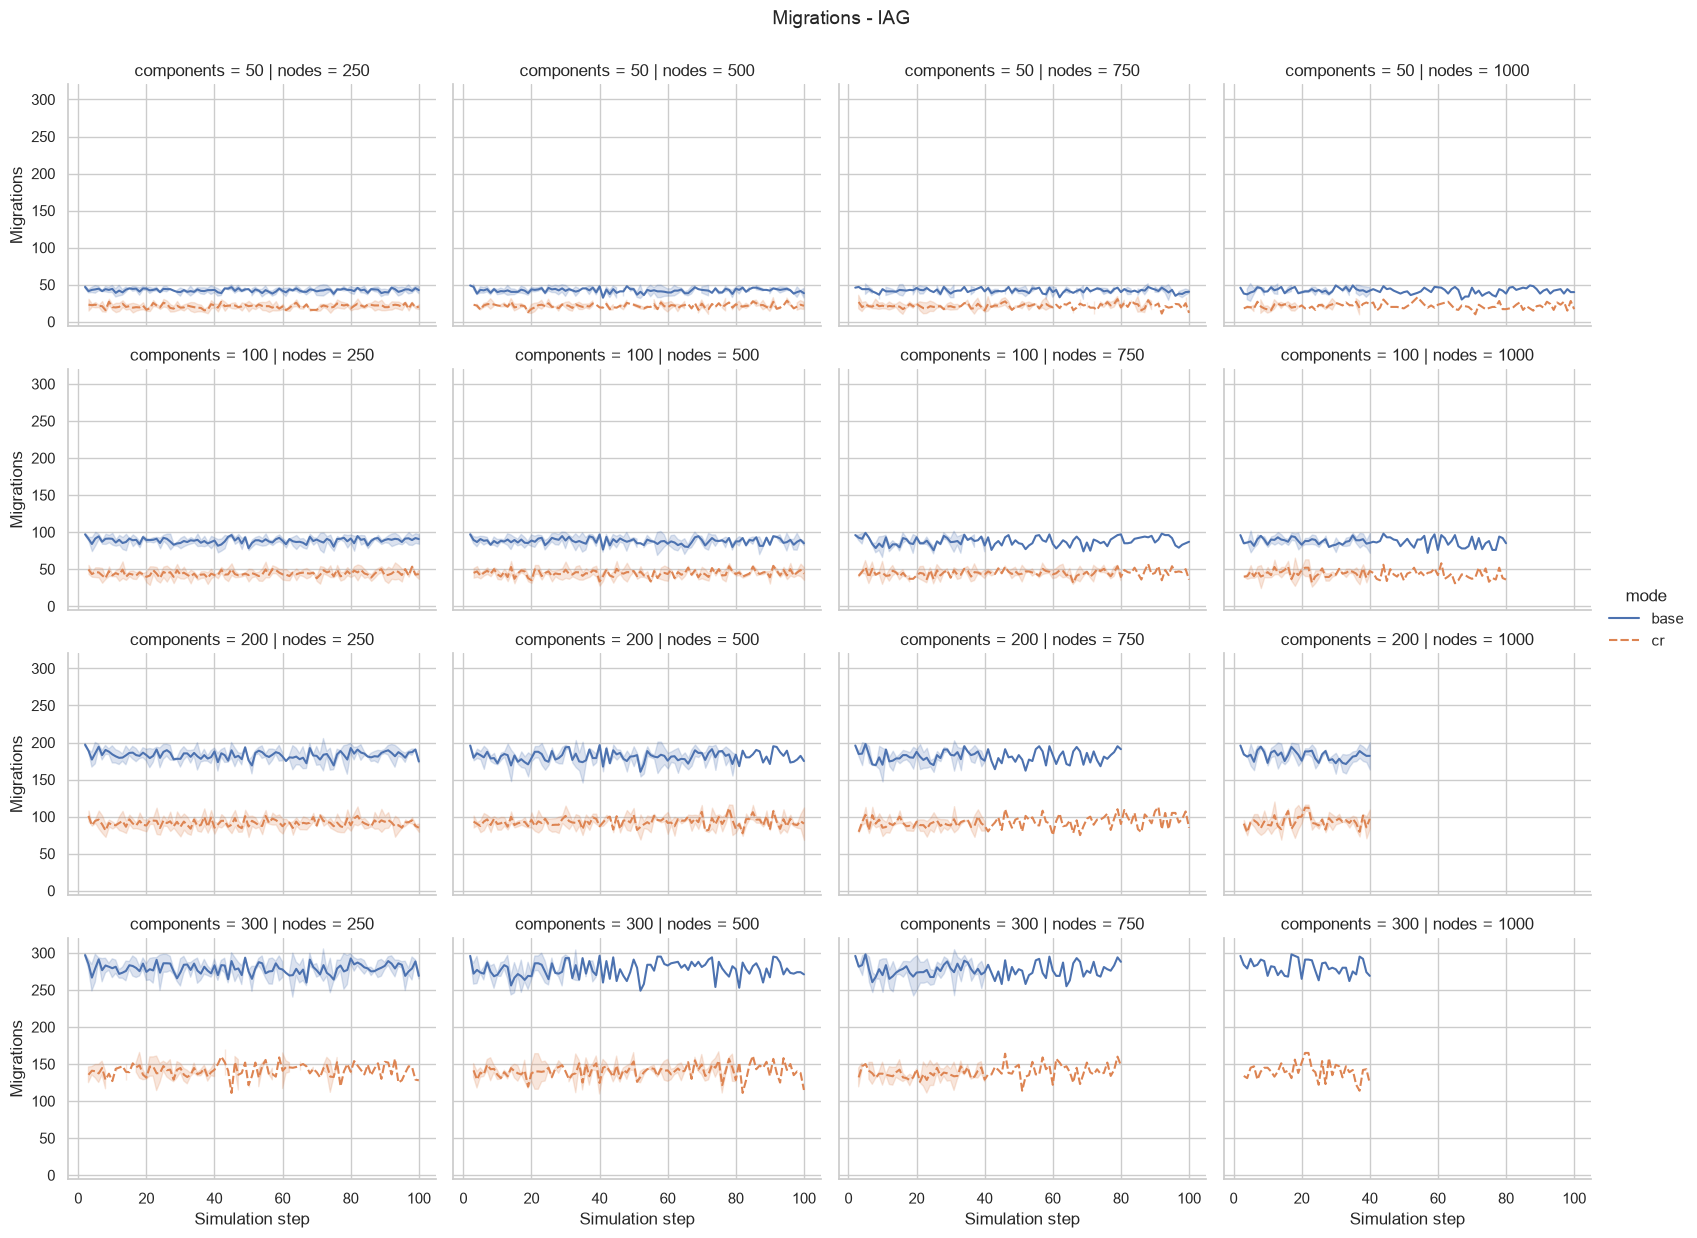

In [10]:
outlier_group_cols = ["mode", "nodes", "components"]

for metric in METRICS:
    for topology in TOPOLOGIES:

        data = plot_df[
            (plot_df["callback_id"] == metric) &
            (plot_df["topology"] == topology)
        ].copy()

        data = data.groupby(outlier_group_cols).apply(remove_outliers_iqr).copy()

        if data.empty:
            print(f"{metric} - {topology}: no data after outlier removal")
            continue

        g = sns.relplot(
            data=data,
            x="n_event",
            y="value",
            hue="mode",
            style="mode",
            col="nodes",
            row="components",
            kind="line",
            errorbar="sd",
            marker=None,
            height=3.0,
            aspect=1.35,
            facet_kws={"sharex": True, "sharey": True},
        )

        g.set_axis_labels("Simulation step", METRIC_LABELS[metric])
        g.set_titles(
            row_template="components = {row_name}",
            col_template="nodes = {col_name}"
        )

        g.figure.suptitle(
            f"{METRIC_LABELS[metric]} - {topology}",
            y=1.03,
            fontsize=14
        )

        for ax in g.axes.flat:
            ax.grid(True)

        plt.show()